Notebook pour analyser/visualiser les filtres (DCT, énergie, métriques, évolution)


# Étape 1 - Import des librairies

In [6]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import sys
sys.path.append(os.path.abspath(".."))
import matplotlib.pyplot as plt

from src.analysis.dct import dct2, idct2, project_filters_to_dct
from src.analysis.model_filters import get_conv3x3_layers, get_layer_filters, iter_conv_kernels
from src.analysis.filter_metrics import (
    compute_dct_coefficients,
    compute_dct_energy,
    compute_total_energy,
    compute_low_frequency_ratio,
    decompose_sym_antisym,
    compute_beta_sq,
    summarize_kernel_metrics,
    summarize_filter_metrics,
    summarize_layer_metrics,
)
from src.analysis.dct_bases import (
    SIGMA_IDX,
    GRAD_X_IDX,
    GRAD_Y_IDX,
    LOW_FREQ_SIGMA_GRAD_MASK,
    DC_ONLY_MASK,
    GRAD_X_ONLY_MASK,
    GRAD_Y_ONLY_MASK,
    GRAD_ONLY_MASK,
    get_dct_basis_3x3,
)

# Etape 2 - Chemin vers le modèle (pour les tests)

In [7]:
MODEL_PATH = "../runs/baseline_resnet20_cifar10_he/model.keras"
model = tf.keras.models.load_model(MODEL_PATH)
print(model.name)

ResNet20


# Etape 3 - Vérifier l'extraction des couches 3x3

Il faut qu'il n'y ait que des couches 3x3

In [8]:
conv3x3_layers = get_conv3x3_layers(model)

print(f"Nombre de couches Conv2D 3x3 : {len(conv3x3_layers)}")
for i, layer in enumerate(conv3x3_layers[:5]):
    print(i, layer.name, layer.kernel_size)

Nombre de couches Conv2D 3x3 : 19
0 conv2d (3, 3)
1 conv2d_1 (3, 3)
2 conv2d_2 (3, 3)
3 conv2d_3 (3, 3)
4 conv2d_4 (3, 3)


# Etape 4 - Tester get_layer_filters

On doit obtenir les détails de la première couche ( (3, 3, 3, 16) )

In [9]:
filters = get_layer_filters(model, 0)
print("Shape filtres première couche :", filters.shape)

Shape filtres première couche : (3, 3, 3, 16)


# Etape 5 - Test DCT / IDCT

L'erreur doit être très proche de 0

In [10]:
kernel = np.array([
    [1., 2., 3.],
    [4., 5., 6.],
    [7., 8., 9.]
])

coeff = dct2(kernel)
recon = idct2(coeff)

print("Erreur reconstruction :", np.abs(kernel - recon).max())

Erreur reconstruction : 5.329070518200751e-15


# Etape 6 - Test Parseval (convservation de l'énergie)

Les énergies doivent être quasiment égales

In [11]:
energy_spatial = np.sum(kernel ** 2)
energy_dct = np.sum(coeff ** 2)

print("Energie spatial :", energy_spatial)
print("Energie DCT :", energy_dct)

Energie spatial : 285.0
Energie DCT : 285.0000000000002


# Etape 7 - Test decompose_sym_antisym

Le produit scalaire doit être proche de 0

In [12]:
kernel = np.array([
    [1., 2., 3.],
    [4., 5., 6.],
    [7., 8., 9.]
])

sym, anti = decompose_sym_antisym(kernel)

print("Reconstruction OK :", np.allclose(kernel, sym + anti))
print("Orthogonalité approx :", np.sum(sym * anti))
print("Sym:")
print(sym)
print("Anti:")
print(anti)

Reconstruction OK : True
Orthogonalité approx : 0.0
Sym:
[[5. 5. 5.]
 [5. 5. 5.]
 [5. 5. 5.]]
Anti:
[[-4. -3. -2.]
 [-1.  0.  1.]
 [ 2.  3.  4.]]


# Etape 8 - Test compute_beta_sq

Cas symétrique : proche de 0


Cas antisymétrique : proche de 1

In [13]:
kernel_sym = np.array([
    [1., 2., 1.],
    [2., 4., 2.],
    [1., 2., 1.]
])

print("beta_sq symétrique :", compute_beta_sq(kernel_sym))

kernel_anti = np.array([
    [-1., 0., 1.],
    [-2., 0., 2.],
    [-1., 0., 1.]
])

print("beta_sq antisymétrique :", compute_beta_sq(kernel_anti))

beta_sq symétrique : 0.0
beta_sq antisymétrique : 1.0


# Etape 9 - Test low_frequency ratio

Cas DC pur : proche de 1


Cas avec bruit : plus bas

In [14]:
kernel_dc = np.ones((3, 3))
filters_4d = kernel_dc[:, :, None, None]

dct_coeffs = compute_dct_coefficients(filters_4d)
dct_energy = compute_dct_energy(dct_coeffs)
ratio = compute_low_frequency_ratio(dct_energy)

print("Low-frequency ratio DC pur :", ratio[0, 0])



np.random.seed(0)
kernel_noise = np.random.randn(3, 3)
filters_4d = kernel_noise[:, :, None, None]

dct_coeffs = compute_dct_coefficients(filters_4d)
dct_energy = compute_dct_energy(dct_coeffs)
ratio = compute_low_frequency_ratio(dct_energy)

print("Low-frequency ratio bruit :", ratio[0, 0])

Low-frequency ratio DC pur : 1.0
Low-frequency ratio bruit : 0.7284378083736992


# Etape 10 - DCT sur une couche du modèle

On attend à ce que les dimensions soient bien conservées

In [15]:
filters = get_layer_filters(model, 0)

dct_coeffs = compute_dct_coefficients(filters)
dct_energy = compute_dct_energy(dct_coeffs)
total_energy = compute_total_energy(dct_energy)
low_ratio = compute_low_frequency_ratio(dct_energy)

print("filters.shape      :", filters.shape)
print("dct_coeffs.shape   :", dct_coeffs.shape)
print("dct_energy.shape   :", dct_energy.shape)
print("total_energy.shape :", total_energy.shape)
print("low_ratio.shape    :", low_ratio.shape)

filters.shape      : (3, 3, 3, 16)
dct_coeffs.shape   : (3, 3, 3, 16)
dct_energy.shape   : (3, 3, 3, 16)
total_energy.shape : (3, 16)
low_ratio.shape    : (3, 16)


# Etape 11 - Statistiques simples sur une couche

On attend que les énergies soient positives et les ratios compris entre 0 et 1

In [16]:
print("Total energy min / max :", total_energy.min(), total_energy.max())
print("Low ratio min / max    :", low_ratio.min(), low_ratio.max())
print("Low ratio mean         :", low_ratio.mean())

Total energy min / max : 0.574833546401303 15.012135694646304
Low ratio min / max    : 0.021182654370884582 0.9418901485547803
Low ratio mean         : 0.5481693582501611


# Etape 12 - Test iter_conv_kernels

On attend que la shape du kernel soit 3x3

In [17]:
first_kernel_info = next(iter_conv_kernels(model))

print(first_kernel_info["layer_idx"])
print(first_kernel_info["layer_name"])
print(first_kernel_info["in_channel"])
print(first_kernel_info["out_channel"])
print(first_kernel_info["kernel"].shape)
print(first_kernel_info["kernel"])

0
conv2d
0
0
(3, 3)
[[-0.19111009 -0.09939549 -0.02660519]
 [-0.59398597 -0.37727618  0.07266741]
 [ 0.01782703 -0.66032857 -0.15044977]]


# Etape 13 - Test summarize_kernel_metrics

On attend les paramètres suivants : total_energy, low_frequency_ratio, beta_sq, dct_coeff_0 à 8, dct_energy_0 à 8

In [18]:
km = summarize_kernel_metrics(
    layer_idx=first_kernel_info["layer_idx"],
    layer_name=first_kernel_info["layer_name"],
    in_channel=first_kernel_info["in_channel"],
    out_channel=first_kernel_info["out_channel"],
    kernel_2d=first_kernel_info["kernel"],
)

print(km.keys())
print(km)

dict_keys(['layer_idx', 'layer_name', 'in_channel', 'out_channel', 'total_energy', 'low_frequency_ratio', 'beta_sq', 'dct_coeff_0', 'dct_coeff_1', 'dct_coeff_2', 'dct_coeff_3', 'dct_coeff_4', 'dct_coeff_5', 'dct_coeff_6', 'dct_coeff_7', 'dct_coeff_8', 'dct_energy_0', 'dct_energy_1', 'dct_energy_2', 'dct_energy_3', 'dct_energy_4', 'dct_energy_5', 'dct_energy_6', 'dct_energy_7', 'dct_energy_8'])
{'layer_idx': 0, 'layer_name': 'conv2d', 'in_channel': 0, 'out_channel': 0, 'total_energy': 1.0065343267477265, 'low_frequency_ratio': 0.5556421775380481, 'beta_sq': 0.37887438008648594, 'dct_coeff_0': -0.6695522715648018, 'dct_coeff_1': -0.2706202350085965, 'dct_coeff_2': 0.3305356286050168, 'dct_coeff_3': 0.19426108495322983, 'dct_coeff_4': -0.16639085114002233, 'dct_coeff_5': -0.34841896301383773, 'dct_coeff_6': 0.16195748579468866, 'dct_coeff_7': 0.3859813655752844, 'dct_coeff_8': 0.11710708340009057, 'dct_energy_0': 0.4483002443575861, 'dct_energy_1': 0.073235311596108, 'dct_energy_2': 0.109

# Etape 14 - Test summarize_filter_metrics

On attend que n_kernels = in_channels et que les moyennes/std soient cohérents

In [19]:
kernel_metrics = []

for info in iter_conv_kernels(model):
    if info["layer_idx"] == 0 and info["out_channel"] == 0:
        kernel_metrics.append(
            summarize_kernel_metrics(
                layer_idx=info["layer_idx"],
                layer_name=info["layer_name"],
                in_channel=info["in_channel"],
                out_channel=info["out_channel"],
                kernel_2d=info["kernel"],
            )
        )

filter_summary = summarize_filter_metrics(kernel_metrics)
print(filter_summary)

{'layer_idx': 0, 'layer_name': 'conv2d', 'out_channel': 0, 'n_kernels': 3, 'total_energy_mean': 1.9478759230313691, 'total_energy_std': 0.9628078354006977, 'low_frequency_ratio_mean': 0.7333526014994058, 'low_frequency_ratio_std': 0.12873829785644003, 'beta_sq_mean': 0.18941780023012553, 'beta_sq_std': 0.1342656073642718, 'dct_coeff_0_mean': -0.0589124957720439, 'dct_coeff_0_std': 1.181355750498698, 'dct_coeff_1_mean': -0.13523641565901914, 'dct_coeff_1_std': 0.13797344441105264, 'dct_coeff_2_mean': 0.046994689662094434, 'dct_coeff_2_std': 0.30386939249693784, 'dct_coeff_3_mean': -0.14202524056265378, 'dct_coeff_3_std': 0.2738991478084884, 'dct_coeff_4_mean': -0.07569167017936708, 'dct_coeff_4_std': 0.1351051540269614, 'dct_coeff_5_mean': -0.19150694895801434, 'dct_coeff_5_std': 0.1415440430767409, 'dct_coeff_6_mean': 0.1847340852718852, 'dct_coeff_6_std': 0.050542770105007365, 'dct_coeff_7_mean': 0.11374747729558005, 'dct_coeff_7_std': 0.28958772159098856, 'dct_coeff_8_mean': 0.248767

# Etape 15 - Test summarize_layer_metrics

On attend que n_kernels = in_channels*out_channels

In [20]:
layer_kernel_metrics = []

for info in iter_conv_kernels(model):
    if info["layer_idx"] == 0:
        layer_kernel_metrics.append(
            summarize_kernel_metrics(
                layer_idx=info["layer_idx"],
                layer_name=info["layer_name"],
                in_channel=info["in_channel"],
                out_channel=info["out_channel"],
                kernel_2d=info["kernel"],
            )
        )

layer_summary = summarize_layer_metrics(layer_kernel_metrics)
print(layer_summary)

{'layer_idx': 0, 'layer_name': 'conv2d', 'n_kernels': 48, 'n_out_channels': 16, 'n_in_channels': 3, 'total_energy_mean': 4.396808422202731, 'total_energy_std': 3.124728448734573, 'low_frequency_ratio_mean': 0.5481693582501611, 'low_frequency_ratio_std': 0.2580862277528588, 'beta_sq_mean': 0.48658769843778105, 'beta_sq_std': 0.2857006348129114, 'dct_coeff_0_mean': -0.025207995480741374, 'dct_coeff_0_std': 0.9545882464077108, 'dct_coeff_1_mean': -0.08475540492793777, 'dct_coeff_1_std': 0.7337953609682183, 'dct_coeff_2_mean': 0.2773738840710794, 'dct_coeff_2_std': 0.597307046079094, 'dct_coeff_3_mean': 0.20006185055320125, 'dct_coeff_3_std': 1.0610321106312002, 'dct_coeff_4_mean': -0.04888175596715886, 'dct_coeff_4_std': 0.6263129894003393, 'dct_coeff_5_mean': -0.08021603653155607, 'dct_coeff_5_std': 0.3832443319400662, 'dct_coeff_6_mean': 0.08290750422096375, 'dct_coeff_6_std': 0.5538409580476598, 'dct_coeff_7_mean': -0.03470517967775001, 'dct_coeff_7_std': 0.5034507853109047, 'dct_coeff

# Etape 16 - DataFrame pour inspection rapide

In [21]:
df_kernel = pd.DataFrame(layer_kernel_metrics)
df_kernel.head()

,layer_idx,layer_name,in_channel,out_channel,total_energy,low_frequency_ratio,beta_sq,dct_coeff_0,dct_coeff_1,dct_coeff_2,...,dct_coeff_8,dct_energy_0,dct_energy_1,dct_energy_2,dct_energy_3,dct_energy_4,dct_energy_5,dct_energy_6,dct_energy_7,dct_energy_8
0,0,conv2d,0,0,1.006534,0.555642,0.378874,-0.669552,-0.270620,0.330536,...,0.117107,0.448300,0.073235,0.109254,0.037737,0.027686,0.121396,0.026230,0.148982,0.013714
1,0,conv2d,0,1,5.806102,0.640995,0.826630,-0.025015,-0.487866,-0.198799,...,-0.231761,0.000626,0.238013,0.039521,3.483042,0.102086,0.241284,0.810657,0.837160,0.053713
2,0,conv2d,0,2,7.065954,0.201462,0.227851,0.167908,-0.241922,0.415567,...,-0.703859,0.028193,0.058526,0.172696,1.336804,4.191716,0.013290,0.567947,0.201364,0.495418
3,0,conv2d,0,3,0.996777,0.157983,0.441809,0.154500,-0.265199,0.221353,...,-0.391561,0.023870,0.070331,0.048997,0.063273,0.124095,0.141989,0.206109,0.164793,0.153320
4,0,conv2d,0,4,0.593727,0.458326,0.256239,-0.467999,-0.196835,0.417401,...,0.148579,0.219023,0.038744,0.174223,0.014354,0.022943,0.011907,0.003326,0.087132,0.022076


In [22]:
df_kernel[["total_energy", "low_frequency_ratio", "beta_sq"]].describe()

,total_energy,low_frequency_ratio,beta_sq
count,48.000000,48.000000,48.000000
mean,4.396808,0.548169,0.486588
std,3.157795,0.260817,0.288724
min,0.574834,0.021183,0.020655
25%,1.825564,0.380487,0.204956
50%,4.285693,0.581074,0.515695
75%,5.826503,0.763785,0.740729
max,15.012136,0.941890,0.965529


# Etape 17 - Vérifier les indices des masques

In [23]:
print("SIGMA_IDX :", SIGMA_IDX)
print("GRAD_X_IDX:", GRAD_X_IDX)
print("GRAD_Y_IDX:", GRAD_Y_IDX)

SIGMA_IDX : (0, 0)
GRAD_X_IDX: (0, 1)
GRAD_Y_IDX: (1, 0)


# Etape 18 - Vérifier les masques

In [24]:
print("LOW_FREQ_SIGMA_GRAD_MASK")
print(LOW_FREQ_SIGMA_GRAD_MASK.astype(int))

print("\nDC_ONLY_MASK")
print(DC_ONLY_MASK.astype(int))

print("\nGRAD_X_ONLY_MASK")
print(GRAD_X_ONLY_MASK.astype(int))

print("\nGRAD_Y_ONLY_MASK")
print(GRAD_Y_ONLY_MASK.astype(int))

print("\nGRAD_ONLY_MASK")
print(GRAD_ONLY_MASK.astype(int))

LOW_FREQ_SIGMA_GRAD_MASK
[[1 1 0]
 [1 0 0]
 [0 0 0]]

DC_ONLY_MASK
[[1 0 0]
 [0 0 0]
 [0 0 0]]

GRAD_X_ONLY_MASK
[[0 1 0]
 [0 0 0]
 [0 0 0]]

GRAD_Y_ONLY_MASK
[[0 0 0]
 [1 0 0]
 [0 0 0]]

GRAD_ONLY_MASK
[[0 1 0]
 [1 0 0]
 [0 0 0]]


# Etape 19 - Générer la base DCT 3x3 et afficher les 9 bases

Shape de la base : (3, 3, 3, 3)


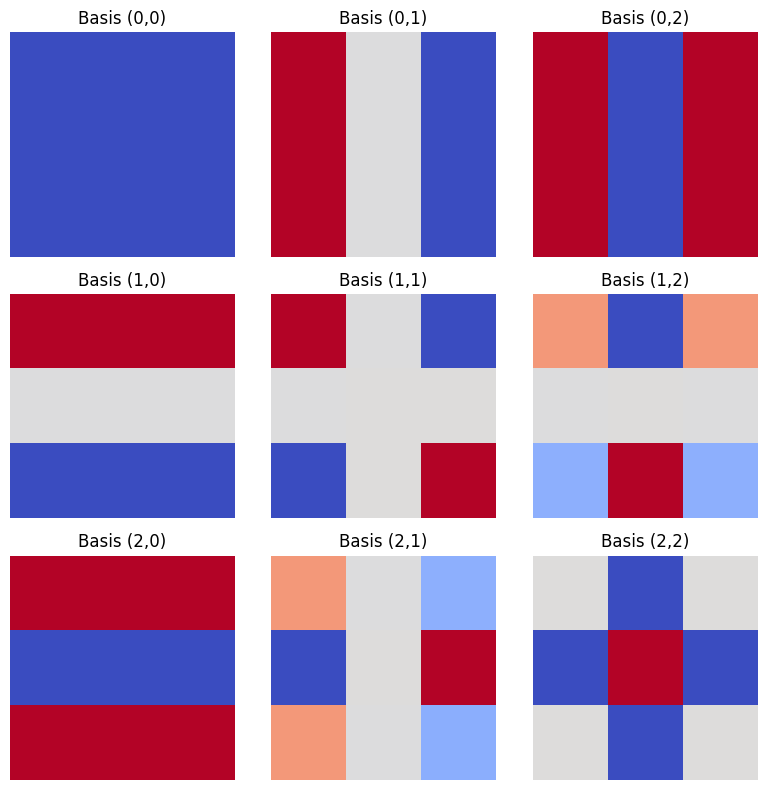

In [25]:
basis = get_dct_basis_3x3()
print("Shape de la base :", basis.shape)
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for u in range(3):
    for v in range(3):
        ax = axes[u, v]
        ax.imshow(basis[u, v], cmap="coolwarm")
        ax.set_title(f"Basis ({u},{v})")
        ax.axis("off")

plt.tight_layout()
plt.show()